In [ ]:
# del F
import pickle
from timeit import default_timer

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Adam import Adam
from utilities3 import *


torch.manual_seed(2)
np.random.seed(2)

if torch.cuda.is_available():
    print("CUDA is available. GPU will be used.")
    device = torch.device('cuda:0')
else:
    print("CUDA is not available. CPU will be used.")
    device = torch.device("cpu")

CUDA is available. GPU will be used.


In [2]:
torch.cuda.is_available()

True

Vanila $\psi$- FNO

In [3]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_high):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = modes_high  #Number of Fourier modes to multiply, at most floor(N/2) + 1
        
        self.scale = (1 / (in_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes_high, dtype=torch.cfloat))
    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        if len(input.shape) == 3:
            return torch.einsum("bix,iox->box", input, weights)
        elif len(input.shape) == 4:
            return torch.einsum("dbix,iox->dbox", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        Nt = x.shape[1]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        if len(x.shape) == 3:
            out_ft = torch.zeros(
                batchsize,
                self.out_channels,
                x.size(-1) // 2 + 1,
                device=x.device,
                dtype=torch.cfloat,
            )
            out_ft[:, :, : self.modes_high :] = self.compl_mul1d(
                x_ft[:, :, : self.modes_high], self.weights
            )
        elif len(x.shape) == 4:
            out_ft = torch.zeros(
                batchsize,
                Nt,
                self.out_channels,
                x.size(-1) // 2 + 1,
                device=x.device,
                dtype=torch.cfloat,
            )
            out_ft[:, :, :, : self.modes_high :] = self.compl_mul1d(
                x_ft[:, :, :, : self.modes_high], self.weights
            )
        # Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class FNO1d(nn.Module):
    def __init__(self, modes_high, width, depth, kernz, noise_dim=1):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes_high = modes_high
        self.width = width
        self.depth = depth
        self.kernelsize = kernz
        self.padding = 2  # pad the domain if input is non-periodic
        self.noise_dim = noise_dim
        self.fc0 = nn.Linear(
            1 + self.noise_dim, self.width, bias=False
        )  # input channel is 2: (a(x), x)

        self.fouriers = nn.ModuleList(
            [
                SpectralConv1d(self.width, self.width, self.modes_high)
                for i in range(self.depth)
            ]
        )
        self.convs = nn.ModuleList(
            [
                nn.Conv1d(
                    self.width,
                    self.width,
                    self.kernelsize,
                    padding=int(self.kernelsize / 2),
                )
                for i in range(self.depth)
            ]
        )
        self.noise_dim = noise_dim

        self.relu = nn.GELU()

        self.fc1 = nn.Linear(self.width, 128, bias=False)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        # x0 = x

        for i in range(self.depth):
            x1 = self.fouriers[i](x)
            # x2 = self.convs[i](x)

            # x = self.relu(x1 + x2 + x0)
            # x0 = x
            x = self.relu(x1)

        # x = x[..., :-self.padding] # pad the domain if input is non-periodic
        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

    def forward_k(self, x, k):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        for i in range(k):
            x1 = self.fouriers[i](x)

            x = x1

        return x

    def forward_k_act(self, x, k):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)

        x = self.fc0(x)

        x = x.permute(0, 2, 1)

        for i in range(k):
            x1 = self.fouriers[i](x)

            x = self.relu(x1)

        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

In [4]:
# %%
################################################################
# fourier layer
################################################################
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        """
        2D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = (
            modes1  # Number of Fourier modes to multiply, at most floor(N/2) + 1
        )
        self.modes2 = modes2

        self.scale = (1 / (in_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

        self.hypernetwork = nn.Sequential(
          nn.Linear(self.in_channels,64),
          nn.PReLU(),
            nn.Linear(64,64),
          nn.PReLU(),
          nn.Linear(64, self.out_channels**2)
        )
        self.hypernetwork1 = nn.Sequential(
          nn.Linear(self.in_channels,64),
          nn.PReLU(),
            nn.Linear(64,64),
          nn.PReLU(),
          nn.Linear(64, self.out_channels)
        )
        self.hypernetwork2 = nn.Sequential(
          nn.Linear(self.in_channels,64),
          nn.PReLU(),
            nn.Linear(64,64),
          nn.PReLU(),
          nn.Linear(64, self.out_channels**2)
        )
        self.hypernetwork3 = nn.Sequential(
          nn.Linear(self.in_channels,64),
          nn.PReLU(),
            nn.Linear(64,64),
          nn.PReLU(),
          nn.Linear(64, self.out_channels)
        )

    # Complex multiplication
    def compl_mul2d(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,ioxy->boxy", input, weights)
    def compl_mul2d2(self, input, weights):
        # (batch, in_channel, x,y ), (in_channel, out_channel, x,y) -> (batch, out_channel, x,y)
        return torch.einsum("bixy,bioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)
        hypercoeff = torch.flatten(self.hypernetwork(x.permute(0,2,3,1)),start_dim=1)[:,:self.in_channels*self.out_channels*self.modes1*self.modes2].reshape([batchsize, self.in_channels, self.out_channels, self.modes1, self.modes2]).to(dtype=torch.cfloat)
        hypercoeff1 = torch.flatten(self.hypernetwork(x.permute(0,2,3,1)),start_dim=1)[:,:self.out_channels*self.modes1*self.modes2].reshape([batchsize, self.out_channels, self.modes1, self.modes2]).to(dtype=torch.cfloat)
        hypercoeff2 = torch.flatten(self.hypernetwork(x.permute(0,2,3,1)),start_dim=1)[:,:self.in_channels*self.out_channels*self.modes1*self.modes2].reshape([batchsize, self.in_channels, self.out_channels, self.modes1, self.modes2]).to(dtype=torch.cfloat)
        hypercoeff3 = torch.flatten(self.hypernetwork(x.permute(0,2,3,1)),start_dim=1)[:,:self.out_channels*self.modes1*self.modes2].reshape([batchsize, self.out_channels, self.modes1, self.modes2]).to(dtype=torch.cfloat)
        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels,  x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        #out_ft[:, :, :self.modes1, :self.modes2] = \
        #    self.compl_mul2d2(x_ft[:, :, :self.modes1, :self.modes2], 0.01*hypercoeff)+0.01*hypercoeff1
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        #out_ft[:, :, :self.modes1, :self.modes2] = \
        #    self.compl_mul2d2(x_ft[:, :, :self.modes1, :self.modes2], 0.01*hypercoeff2)+0.01*hypercoeff3
        #Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x


class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(FNO2d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution 
        output shape: (batchsize, x=s, y=s, c=1)
        """

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.fc0 = nn.Linear(3, self.width)  # input channel is 3: (a(x, y), x, y)

        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        #self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        #self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        #self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        #self.w1 = nn.Conv2d(self.width, self.width, 1)
        #self.w2 = nn.Conv2d(self.width, self.width, 1)
        #self.w3 = nn.Conv2d(self.width, self.width, 1)

        #self.fouriers = nn.ModuleList([SpectralConv1d(self.width, self.width, self.modes_high) for i in range(self.depth)])
        #self.convs = nn.ModuleList([nn.Conv1d(self.width, self.width, self.kernelsize, padding = int(self.kernelsize/2)) for i in range(self.depth)])
        self.relu = nn.GELU()



        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y = x.shape[1], x.shape[2]

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        x1 = self.conv0(x)
        x2 = self.w0(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        '''

        x1 = self.conv1(x)
        x2 = self.w1(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        x = self.relu(x)

        x1 = self.conv3(x)
        x2 = self.w3(x.view(batchsize, self.width, -1)).view(
            batchsize, self.width, size_x, size_y
        )
        x = x1 + x2
        '''

        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

#%%




In [5]:
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes_high):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes_high = modes_high  #Number of Fourier modes to multiply, at most floor(N/2) + 1
        
        self.scale = (1 / (in_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes_high, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        if len(input.shape) == 3:
            return torch.einsum("bix,biox->box", input, weights)
        elif len(input.shape) == 4:
            return torch.einsum("btix,biox->btox", input, weights)

    def forward(self, x, weight = 1):
        batchsize = x.shape[0]
        Nt= x.shape[1]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        #print(x_ft.shape,'dd')
        if len(x.shape) == 3:
            out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
            out_ft[:, :,:self.modes_high:] = self.compl_mul1d(x_ft[:, :, :self.modes_high], self.weights.unsqueeze(0)*weight)
        elif len(x.shape) == 4:
            out_ft = torch.zeros(batchsize, Nt, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
            out_ft[:, :,:,:self.modes_high:] = self.compl_mul1d(x_ft[:,:, :, :self.modes_high], self.weights.unsqueeze(0)*weight)
        #Return to physical space

        #print(self.weights.shape, weight.shape)
        out_ft = out_ft
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x


class ContextFNO(nn.Module):
    def __init__(self, modes1, modes2,  mode1d, width, depth):
        super(ContextFNO, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the coefficient function and locations (a(x, y), x, y)
        input shape: (batchsize, x=s, y=s, c=3)
        output: the solution 
        output shape: (batchsize, x=s, y=s, c=1)
        """
        self.depth = depth
        self.mode1d = mode1d
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 0 # pad the domain if input is non-periodic
        self.fc0 = nn.Linear(38400, 1000) # input channel is 3: (a(x, y), x, y)

        '''
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
        '''

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)


        '''
        self.fourierscontext = nn.ModuleList([SpectralConv2d(self.width, self.width, self.mode1d, self.modes2) for i in range(3*self.depth)])
        self.convscontext = nn.ModuleList([ nn.Conv2d(self.width, self.width, 1) for i in range(3*self.depth)])
        self.fourierscontextbias = nn.ModuleList([SpectralConv1d(self.width, self.width, self.mode1d) for i in range(self.depth)])
        self.convscontextbias = nn.ModuleList([nn.Conv1d(self.width, self.width, 1, padding = 0) for i in range(self.depth)])
        '''
        self.fouriers = nn.ModuleList([SpectralConv1d(self.width, self.width, self.mode1d) for i in range(self.depth)])
        self.convs = nn.ModuleList([nn.Conv1d(self.width, self.width, 1, padding = 0) for i in range(self.depth)])
        
        self.linearscontext = nn.ModuleList([nn.Linear(1000,500),nn.Linear(500,500)])

        self.fc1 = nn.Linear(500, self.mode1d*self.width**2 )

        self.fc00 = nn.Linear(5, self.width, bias=False) # input channel is 2: (a(x), x)


        self.fc10 = nn.Linear(self.width, 128,  bias=False)
        self.fc20 = nn.Linear(128, 1)


    def forward(self, x, x0):



        #print(x.shape)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = x.reshape(x.shape[0],-1)
        #print(x.shape)
        grid1d = self.get_grid1d(x0.shape, x0.device)
        x0 = torch.cat((x0, grid1d), dim=-1)


        x = self.fc0(x)

        x0 = self.fc00(x0)


        
        x0 = x0.permute(0, 2, 1)


        for i in range(2):

            x = F.gelu(self.linearscontext[i](x))

        x = self.fc1(x)

        for i in range(self.depth):

    
            x1 = self.fouriers[i](x0,x.reshape([x.shape[0],self.width, self.width, self.mode1d]))
            x2 = self.convs[i](x0)
   
            x0 = F.gelu((x1)) + x0 #+ xcb


        x0 = x0.permute(0, 2,1)

        x0 = self.fc10(x0)
        x0 = F.gelu(x0)
        x0 = self.fc20(x0)

        return x0

    def train_forward(self, x, x0):



        #print(x.shape)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = x.reshape(x.shape[0],-1)
        #print(x.shape)
        grid1d_train = self.get_grid1d_train(x0.shape, x0.device)
        x0 = torch.cat((x0, grid1d_train), dim=-1)


        x = self.fc0(x)

        x0 = self.fc00(x0)


        
        x0 = x0.permute(0, 2, 3, 1)

        orig_shape = x0.shape
        B, N, A, D = orig_shape 
        for i in range(2):

            x = F.gelu(self.linearscontext[i](x))

        x = self.fc1(x)

        for i in range(self.depth):

    
            x1 = self.fouriers[i](x0,x.reshape([x.shape[0],self.width, self.width, self.mode1d]))
            x2 = self.convs[i](x0.reshape(B*N,A, D).contiguous()).reshape(B, N, A, D)  
   
            x0 = F.gelu((x1)) + x0 #+ xcb


        x0 = x0.permute(0, 3, 1, 2)

        x0 = self.fc10(x0)
        x0 = F.gelu(x0)
        x0 = self.fc20(x0)

        return x0

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)

    def get_grid1d(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)

    def get_grid1d_train(self, shape, device):
        batchsize, size_x, N_t = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, N_t, 1])
        return gridx.to(device)


# %%

In [6]:
import pickle

with open(file='trainingdataset_no_source_01_500_100_05.pickle', mode='rb') as f:
    dataset=pickle.load(f)[:,:]


with open(file='testdataset_no_source_01_5_100_05.pickle', mode='rb') as f:
    testset=pickle.load(f)

In [7]:
XX.reshape(XX.shape[0],-1).shape

NameError: name 'XX' is not defined

In [8]:
XX = dataset[:,:,:50,0].unsqueeze(-1).to(device)
consiI = dataset[:,:,:50,1].unsqueeze(-1).to(device)

In [9]:
xl = torch.cat((x, torch.roll(x, -1, dims=1)), dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims=1)), dim=3)

NameError: name 'x' is not defined

In [10]:
XX.shape

torch.Size([500, 256, 50, 1])

In [29]:
learning_rate = 0.001
step_size = 100
re = 3
gamma = 0.5
model = ContextFNO(8,4,32,128,5).to(device)

print(count_params(model))
lambd = 5

################################################################
# training and evaluation
################################################################
optimizer = Adam(model.parameters(), lr=learning_rate, weight_decay=re * 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

myloss = LpLoss(size_average=True)
myloss2 = LpLoss(size_average=True)
for ep in range(2000):

    for j in range(20):
        x = XX[5*j:5*(j+1)]
        consi = consiI[5*j:5*(j+1)]
        model.train()
        t1 = default_timer()
        train_mse = 0
        train_l2 = 0
        train_l2_2 = 0
        
    
        optimizer.zero_grad()
    
        xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
        xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)
    
        f0 = model.train_forward(x,xl)
        f1 = model.train_forward(x,xr)
                
        l2_tm = lambd*myloss(((0.128))*(f0-f1)[:,:,0:99,0], (torch.roll(x, -1, dims = 2)-x)[:,:,0:99,0].detach())
    
        MM = model.train_forward(x, torch.cat((x,x,x,x), dim = 3))
        
        train_l2_tm = l2_tm.item()
        l2_F = myloss(MM, consi) #Burgers
        #l2_F_roll = myloss(torch.roll(F,128,dims=1), torch.roll(FF,128,dims=1).detach()) #Burgers
        #l2 += myloss(F, x[0].cuda()) #advection
        l2 = l2_tm + l2_F 
        l2.backward() # use the l2 relative loss
        train_l2_consi = l2_F.item()
        optimizer.step()
    
        #print(l2_tm, l2_F)
                

        

    scheduler.step()
    model.eval()

    print(ep, train_l2_tm/lambd, train_l2_consi)

    t2 = default_timer()

    

307163010
0 1.0039863586425781 0.5014576315879822
1 1.0022098541259765 0.49079179763793945
2 1.0015830993652344 0.4998035132884979
3 1.0009535789489745 0.46204543113708496
4 0.9999144554138184 0.4761742651462555
5 1.001087760925293 0.48417922854423523
6 0.9989889144897461 0.44855520129203796
7 0.9993488311767578 0.4390126168727875
8 0.9982001304626464 0.4422040581703186
9 0.997863483428955 0.44033652544021606
10 0.9973307609558105 0.4198113977909088
11 0.9964606285095214 0.4450696110725403
12 0.9957099914550781 0.42171669006347656
13 0.996065616607666 0.4172030985355377
14 0.9966510772705078 0.4591262936592102
15 0.9960951805114746 0.44681379199028015
16 0.9948694229125976 0.4417886435985565
17 0.9944178581237793 0.4555898606777191
18 0.9916740417480469 0.42732009291648865
19 0.9879060745239258 0.3911593556404114
20 0.9887086868286132 0.42644378542900085
21 0.98770751953125 0.4113645553588867
22 0.9864160537719726 0.4153566360473633
23 0.9846337318420411 0.4116927683353424
24 0.9762966

In [ ]:
print(l2_tm, l2_F)

In [104]:
MM.shape, consi.shape

(torch.Size([1, 256, 50, 1]), torch.Size([1, 256, 50, 1]))

In [30]:
import pickle


with open(file='trained_model.pickle', mode='wb') as f:
    pickle.dump(model, f)

In [27]:
torch.save(model.state_dict(), "contextfno_state_22.pth")

NameError: name 'model' is not defined

In [28]:
model = ContextFNO(8,4,8,16,3).to(device)
model.load_state_dict(torch.load("contextfno_state_22.pth", map_location=device))

NameError: name 'SpectralConv2d' is not defined

In [31]:
x = dataset[:1,:,0,0].unsqueeze(-1).to(device)
X = dataset[:1,:,:,0].unsqueeze(-1).to(device)
y = []
xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
model.to(device)
f0 = model.forward(X,xl)
f1 = model.forward(X,xr)
        
for i in range(20):

    x = x +(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=2)
    xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=2)
    
    
    f0 = model.forward(X,xl)
    f1 = model.forward(X,xr)
            

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x76800 and 38400x128)

In [30]:
j = 1
x = XX[5*j:5*(j+1)]
consi = consiI[5*j:5*(j+1)]
model.train()
t1 = default_timer()
train_mse = 0
train_l2 = 0
train_l2_2 = 0


xl = torch.cat((torch.roll(x, -2, dims = 1),torch.roll(x, -1, dims = 1), x,torch.roll(x, 1, dims = 1)),dim=3)
xr = torch.cat((torch.roll(x, -1, dims = 1),x, torch.roll(x, 1, dims = 1), torch.roll(x, 2, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)

NameError: name 'model' is not defined

In [102]:
dataset[:2,:,0,0].unsqueeze(-1).to(device).shape

torch.Size([2, 256, 1])

In [103]:
dataset[:1,:,:,0].unsqueeze(-1).to(device).shape

torch.Size([1, 256, 50, 1])

In [152]:
((torch.sum(XX, dim=3).unsqueeze(2)).permute(0, 3, 1, 2).flatten(start_dim=0, end_dim=1)).shape

torch.Size([5000, 256, 1])

In [155]:
torch.sum(XX, dim=2).unsqueeze(2).shape

torch.Size([100, 256, 1, 1])

In [156]:
XX.shape

torch.Size([100, 256, 50, 1])

In [33]:
X.shape

torch.Size([1, 256, 100, 1])

In [12]:
model.eval()  # 드롭아웃/BN 고정
NNN = 0
with torch.inference_mode():  # 또는 torch.no_grad()
    x = dataset[NNN:NNN+1,:,0,0].unsqueeze(-1).to(device).detach()
    X = dataset[NNN:NNN+1,:,:50,0].unsqueeze(-1).to(device).detach()

    xl = torch.cat((torch.roll(x, -2, dims=1),
                    torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1)), dim=2)
    xr = torch.cat((torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1),
                    torch.roll(x, 2, dims=1)), dim=2)

    f0 = model.forward(X, xl)  # model.forward(...) 대신 호출 권장
    f1 = model.forward(X, xr)

    for _ in range(10):
        # in-place로 조금 더 절약 가능 (inference_mode에서는 안전)
        x = x + (0.128) * (f0 - f1)

        xl = torch.cat((torch.roll(x, -2, dims=1),
                        torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1)), dim=2)
        xr = torch.cat((torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1),
                        torch.roll(x, 2, dims=1)), dim=2)

        f0 = model.forward(X, xl)
        f1 = model.forward(X, xr)

In [35]:
model.eval()  # 드롭아웃/BN 고정
NNN = 0
with torch.inference_mode():  # 또는 torch.no_grad()
    x = testset[NNN:NNN+1,:,0,0].unsqueeze(-1).to(device).detach()
    X = testset[NNN:NNN+1,:,:50,0].unsqueeze(-1).to(device).detach()

    xl = torch.cat((torch.roll(x, -2, dims=1),
                    torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1)), dim=2)
    xr = torch.cat((torch.roll(x, -1, dims=1),
                    x,
                    torch.roll(x, 1, dims=1),
                    torch.roll(x, 2, dims=1)), dim=2)

    f0 = model.forward(X, xl)  # model.forward(...) 대신 호출 권장
    f1 = model.forward(X, xr)

    for _ in range(20):
        # in-place로 조금 더 절약 가능 (inference_mode에서는 안전)
        x = x + (0.128) * (f0 - f1)

        xl = torch.cat((torch.roll(x, -2, dims=1),
                        torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1)), dim=2)
        xr = torch.cat((torch.roll(x, -1, dims=1),
                        x,
                        torch.roll(x, 1, dims=1),
                        torch.roll(x, 2, dims=1)), dim=2)

        f0 = model.forward(X, xl)
        f1 = model.forward(X, xr)

In [158]:
x = testset[:2,:,:,0].unsqueeze(-1).to(device)

y = []
xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)

f0 = model.train_forward(x,xl)
f1 = model.train_forward(x,xr)
        
for i in range():

    x = x -(0.256)/5*(f0-f1)
    #y.append(x)
    xl = torch.cat((x, torch.roll(x, -1, dims = 1)),dim=3)
    xr = torch.cat((x, torch.roll(x, 1, dims = 1)),dim=3)
    
    f0 = model.train_forward(X,xl)
    f1 = model.train_forward(X,xr)
            

RuntimeError: mat1 and mat2 shapes cannot be multiplied (51200x3 and 5x96)

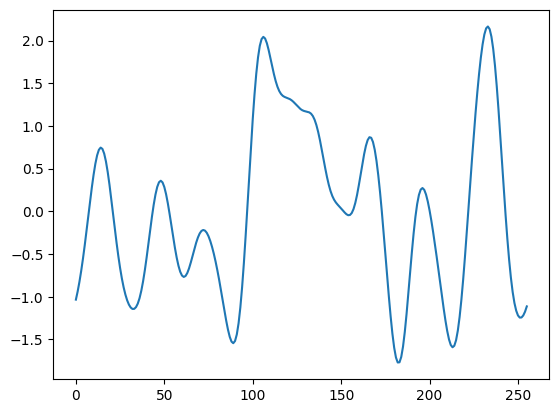

In [14]:
plt.plot(testset.detach().cpu()[0,:,0,0])

In [98]:
x.shape

torch.Size([1, 256, 1])

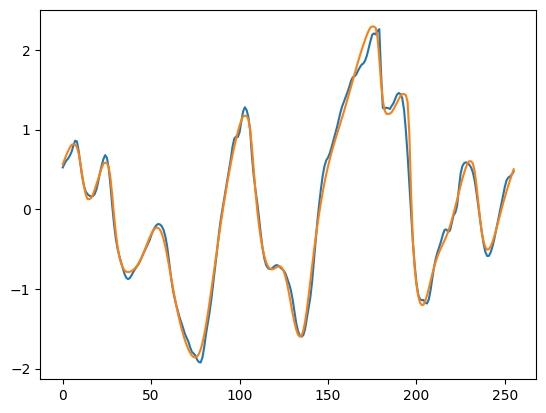

In [36]:
M = 0
plt.plot(x.detach().cpu()[0,:,0])
plt.plot(testset.detach().cpu()[0,:,20,0])

In [89]:
x

tensor([[[nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
         [nan],
        

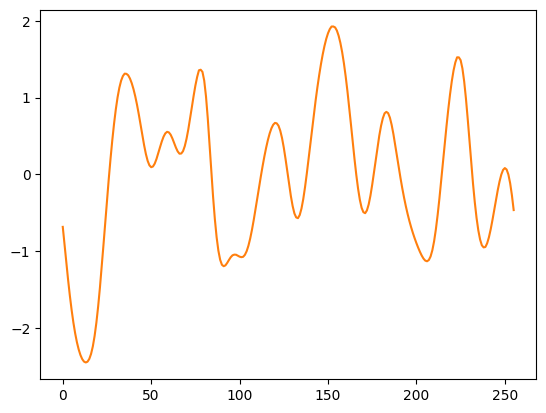

In [19]:


#plt.plot(x[0].detach().cpu()+ 0.256/5*(f0[0,:,:]-f1[0,:,:]).detach().cpu())
#plt.plot(X[0,:,0,:].detach().cpu())
plt.plot(x[0].detach().squeeze().cpu())
plt.plot(X[0,:,99,:].detach().cpu())

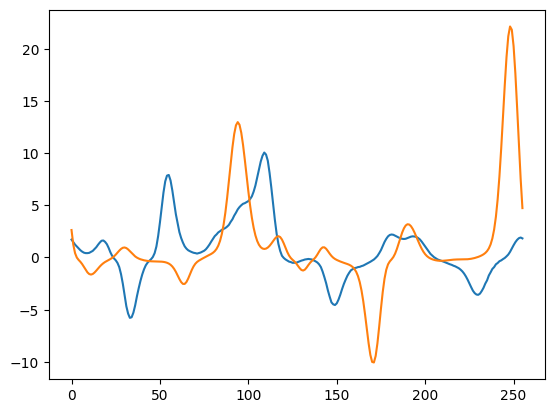

In [21]:
plt.plot(MM.detach().cpu()[0,:,0,0])
plt.plot(dataset[:,:,:,1].unsqueeze(-1).detach().cpu()[0,:,0,0])

In [ ]:
plt.plot(dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,1,0]-dataset[:10,:,:,0].unsqueeze(-1).detach().cpu()[0,:,0,0])